In [1]:
# mount drive
from google.colab import drive
drive.mount('/content/drive')

# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

# importing util
import os
os.chdir('/content/drive/MyDrive/DSSI/Project/code')
import utils

print('finished imports!')

Mounted at /content/drive
finished imports!


In [ ]:
aggregated_data = pd.read_csv('/content/drive/MyDrive/DSSI/Project/Valley Fever - Environmental/data_processed/aggregate/aggregate_all_counties_2001_2024.csv', parse_dates=['Year-Month'])
aggregated_data['log1p_rate_per_100k'] = np.log1p(aggregated_data['rate_per_100k'])

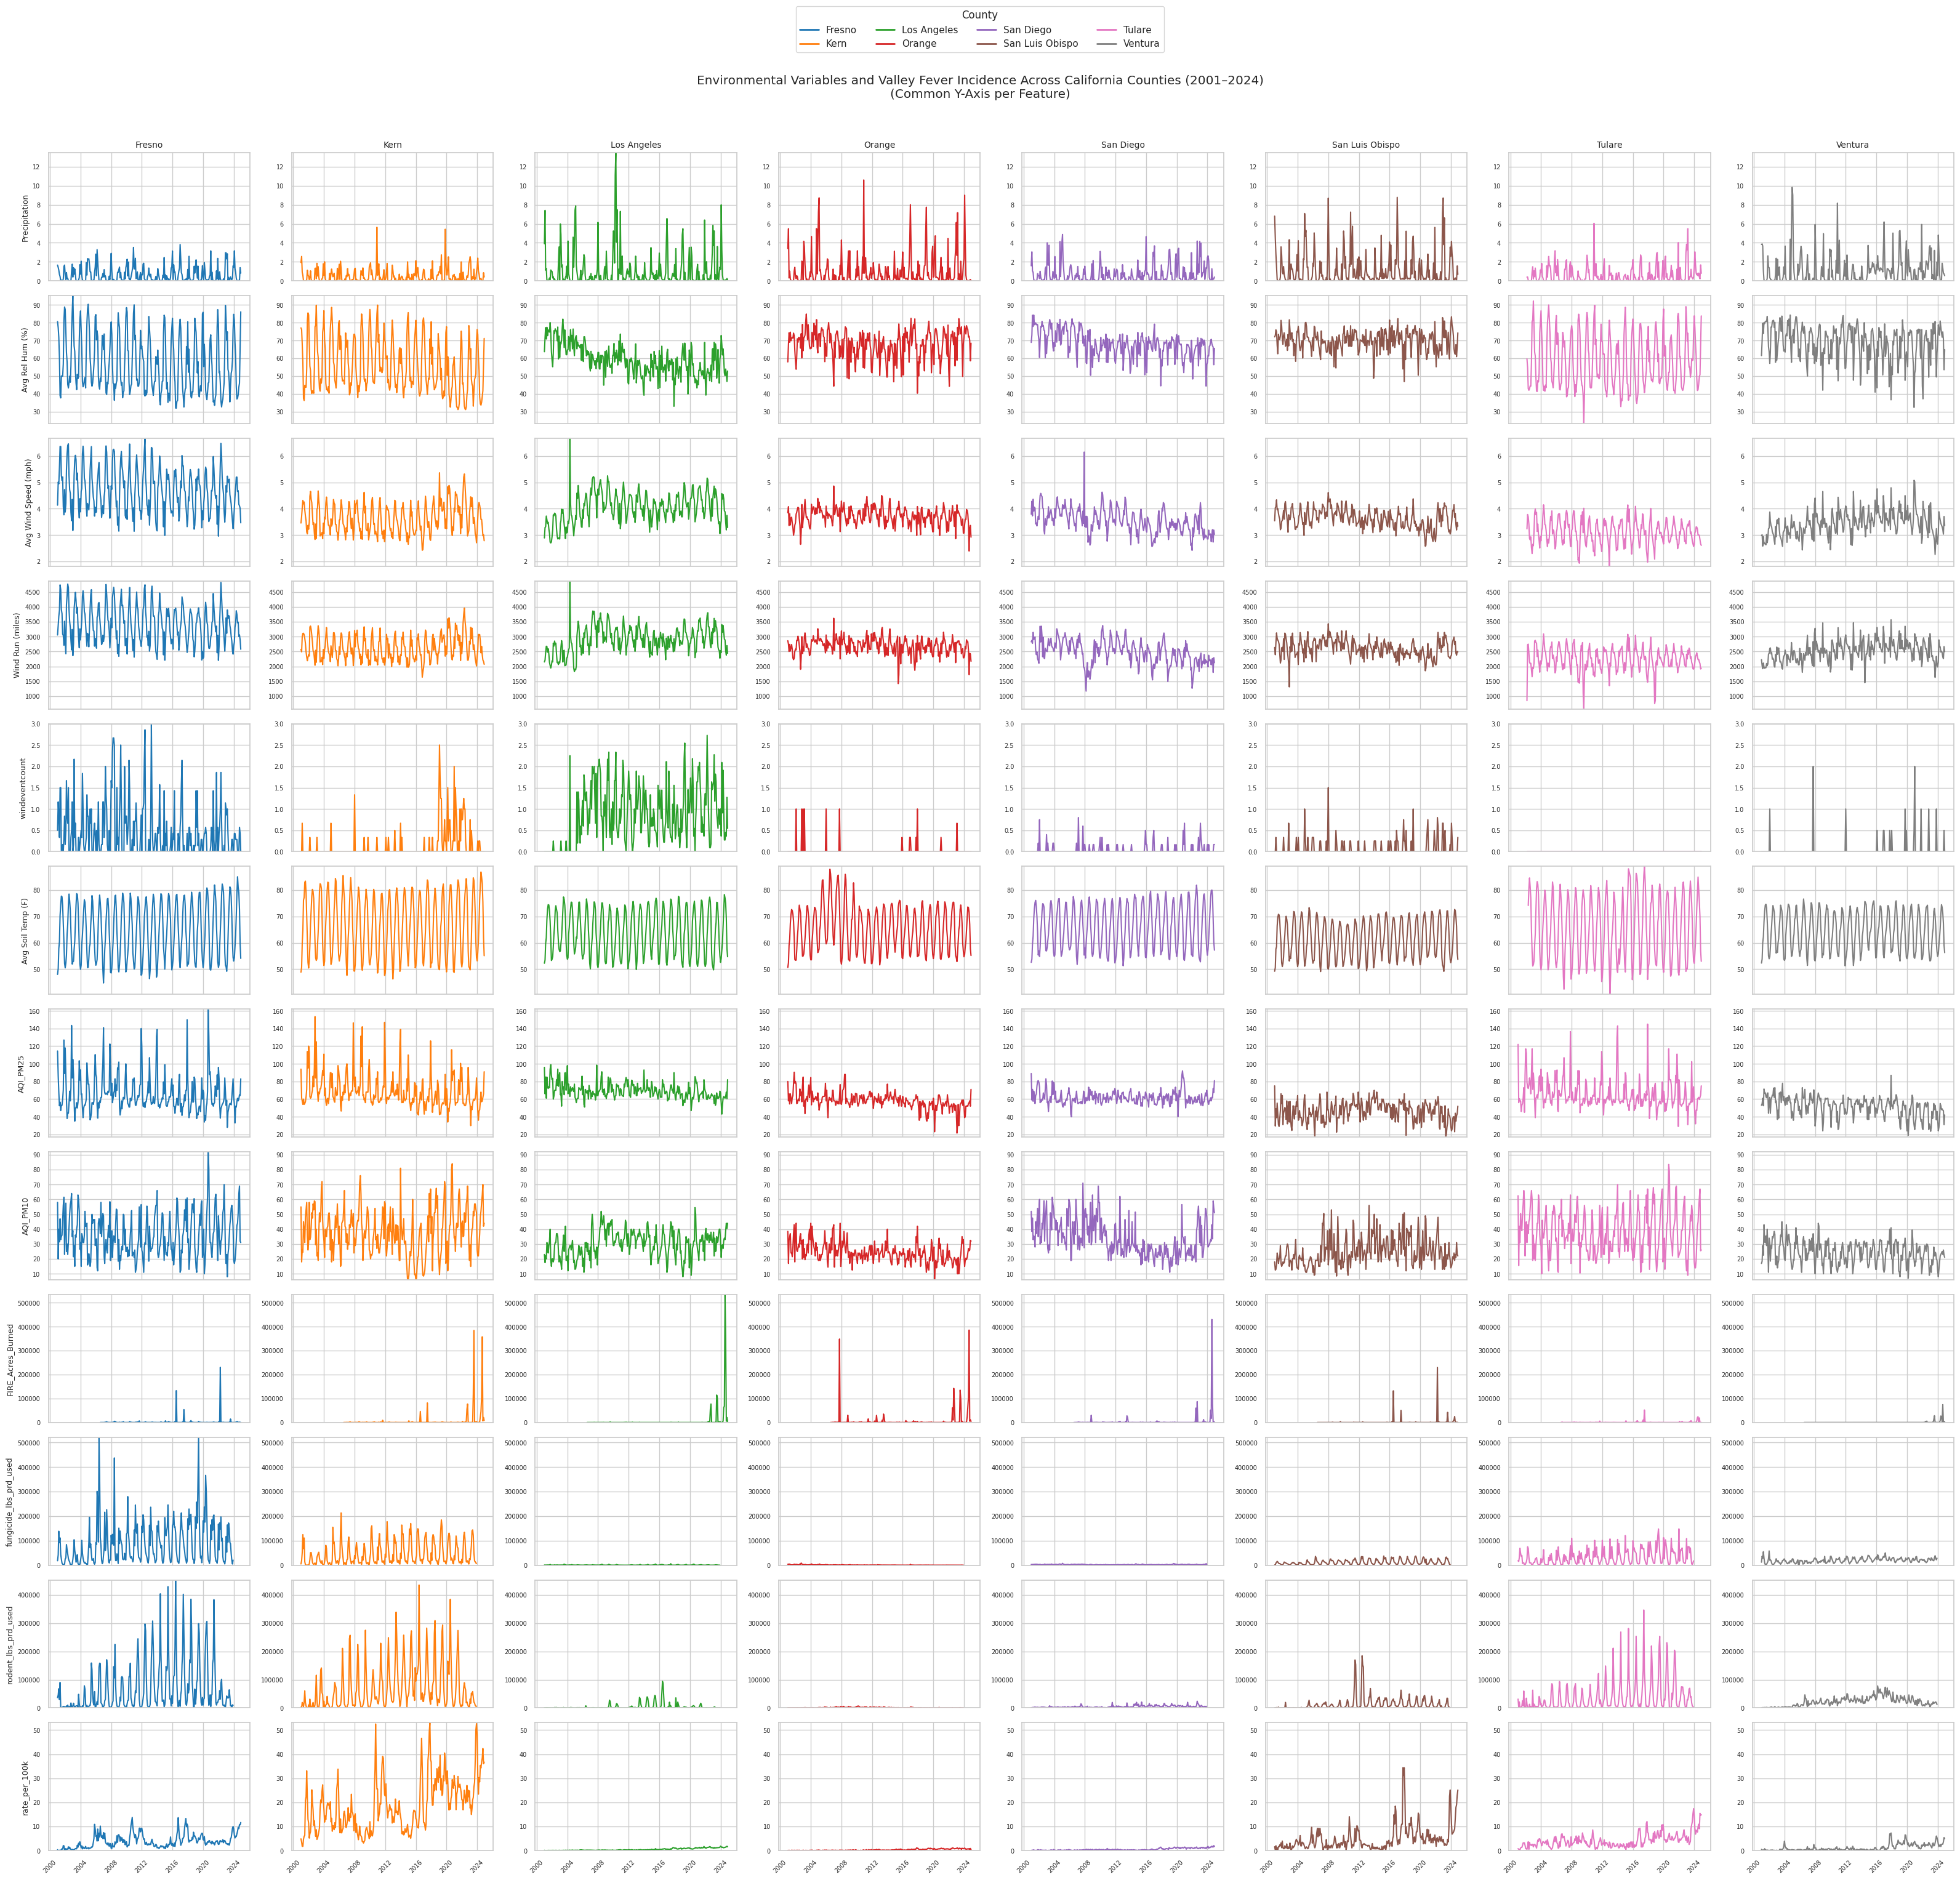

In [ ]:
# @title
features_to_plot = [
    "Precipitation",
    "Avg Rel Hum (%)",
    "Avg Wind Speed (mph)",
    "Wind Run (miles)",
    "windeventcount",
    "Avg Soil Temp (F)",
    "AQI_PM25",
    "AQI_PM10",
    "FIRE_Acres_Burned",
    "fungicide_lbs_prd_used",
    "rodent_lbs_prd_used",
    "rate_per_100k",
]

counties = [
    'Fresno',
    'Kern',
    'Los Angeles',
    'Orange',
    'San Diego',
    'San Luis Obispo',
    'Tulare',
    'Ventura'
]

sns.set_theme(style="whitegrid")

# One consistent color per county
palette = sns.color_palette("tab10", len(counties))
county_colors = dict(zip(counties, palette))

fig, axes = plt.subplots(
    nrows=len(features_to_plot),
    ncols=len(counties),
    figsize=(4 * len(counties), 2.5 * len(features_to_plot)),
    sharex=True
)

for row_idx, feature in enumerate(features_to_plot):
    for col_idx, county in enumerate(counties):
        ax = axes[row_idx, col_idx]

        county_df = aggregated_data[
            aggregated_data["County"] == county
        ].sort_values("Year-Month")

        feature_min = aggregated_data[feature].min(skipna=True)
        feature_max = aggregated_data[feature].max(skipna=True)

        sns.lineplot(
            data=county_df,
            x="Year-Month",
            y=feature,
            ax=ax,
            color=county_colors[county],
            linewidth=1.5
        )

        if row_idx == 0:
            ax.set_title(county, fontsize=10)

        if col_idx == 0:
            ax.set_ylabel(feature, fontsize=9)
        else:
            ax.set_ylabel("")

        ax.set_xlabel("")
        ax.set_ylim(feature_min, feature_max)
        ax.tick_params(axis="x", rotation=45, labelsize=7)
        ax.tick_params(axis="y", labelsize=7)

# Create one legend for the figure
handles = [
    plt.Line2D([0], [0], color=county_colors[county], lw=2, label=county)
    for county in counties
]

fig.suptitle("Environmental Variables and Valley Fever Incidence Across California Counties (2001–2024)" + "\n(Common Y-Axis per Feature)")

fig.legend(
    handles=handles,
    title="County",
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [ ]:
# same y_min and y_max
# able to compare magnitudes
# saved in working directory
fig.savefig("county_feature_grid_ylim.png", dpi=300, bbox_inches="tight")

In [ ]:
features_to_plot = [
    "Precipitation",
    "Avg Rel Hum (%)",
    "Avg Wind Speed (mph)",
    "Wind Run (miles)",
    "windeventcount",
    "Avg Soil Temp (F)",
    "AQI_PM25",
    "AQI_PM10",
    "FIRE_Acres_Burned",
    "fungicide_lbs_prd_used",
    "rodent_lbs_prd_used",
    "rate_per_100k",
]

counties = [
    'Fresno',
    'Kern',
    'Los Angeles',
    'Orange',
    'San Diego',
    'San Luis Obispo',
    'Tulare',
    'Ventura'
]

# Create normalized copy
normalized_data = aggregated_data.copy()

for county in counties:
    mask = normalized_data["County"] == county

    normalized_data.loc[mask, features_to_plot] = (
        MinMaxScaler().fit_transform(
            normalized_data.loc[mask, features_to_plot]
        )
    )

sns.set_theme(style="whitegrid")

# One consistent color per county
palette = sns.color_palette("tab10", len(counties))
county_colors = dict(zip(counties, palette))

fig, axes = plt.subplots(
    nrows=len(features_to_plot),
    ncols=len(counties),
    figsize=(4 * len(counties), 2.5 * len(features_to_plot)),
    sharex=True
)

for row_idx, feature in enumerate(features_to_plot):
    for col_idx, county in enumerate(counties):
        ax = axes[row_idx, col_idx]

        county_df = normalized_data[
            normalized_data["County"] == county
        ].sort_values("Year-Month")

        sns.lineplot(
            data=county_df,
            x="Year-Month",
            y=feature,
            ax=ax,
            color=county_colors[county],
            linewidth=1.5
        )

        if row_idx == 0:
            ax.set_title(county, fontsize=10)

        if col_idx == 0:
            ax.set_ylabel(feature, fontsize=9)
        else:
            ax.set_ylabel("")

        ax.set_xlabel("")
        ax.set_ylim(0,1)
        ax.tick_params(axis="x", rotation=45, labelsize=7)
        ax.tick_params(axis="y", labelsize=7)

# Create one legend for the figure
handles = [
    plt.Line2D([0], [0], color=county_colors[county], lw=2, label=county)
    for county in counties
]

fig.suptitle("Normalized Environmental Variables and Valley Fever Incidence Across California Counties (2001–2024)" + "\n(Values are min-max normalized within each county to facilitate comparison of temporal patterns)")

fig.legend(
    handles=handles,
    title="County",
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# normalized values (0-1)
# compare temporal patterns and seasonality
# saved in working directory
fig.savefig("county_feature_grid_normalized.png", dpi=300, bbox_inches="tight")

In [ ]:
monthly_all_df = pd.read_csv('/content/drive/MyDrive/DSSI/Project/code/monthly_dataset.csv', parse_dates=['Year-Month'])
monthly_all_df['log1p_rate_per_100k'] = np.log1p(monthly_all_df['rate_per_100k'])

# trimmed dataframe
# fire data starts 2006-08
# fungicide/rodentcide data ends 2023-12
monthly_all_trimmed = monthly_all_df[(monthly_all_df["Year-Month"] >= "2006-08-01") & (monthly_all_df["Year-Month"] <= "2023-12-01")].copy()

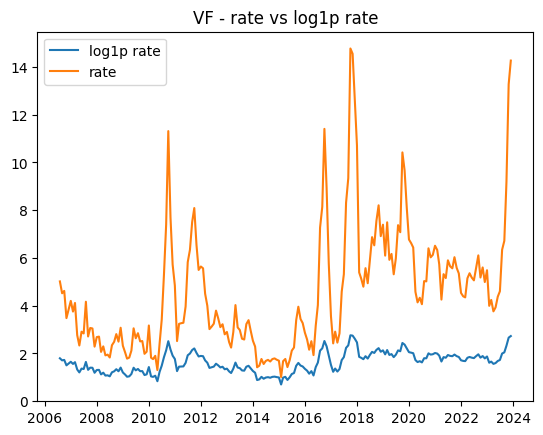

In [ ]:
plt.plot(monthly_all_trimmed['Year-Month'], monthly_all_trimmed['log1p_rate_per_100k'], label='log1p rate')
plt.plot(monthly_all_trimmed['Year-Month'], monthly_all_trimmed['rate_per_100k'], label='rate')
plt.title("VF - rate vs log1p rate")
plt.legend()